In [1]:
import pandas as pd
import feature_selection as fs
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

In [2]:
# Split rookie dataset

rookie_df = fs.load_rookie_features()

X = rookie_df.drop(columns=['Player', 'AS_After_Year_Two'])
y = rookie_df['AS_After_Year_Two']

training_df = rookie_df[rookie_df['Rookie_Season'] <= 2018]
testing_df = rookie_df[rookie_df['Rookie_Season'] > 2018]

X_train = training_df.drop(columns=['Player', 'AS_After_Year_Two'])
y_train = training_df['AS_After_Year_Two']

X_test = testing_df.drop(columns=['Player', 'AS_After_Year_Two'])
y_test = testing_df['AS_After_Year_Two']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1961, 26)
(1961,)
(496, 26)
(496,)


In [3]:
# Initialize and train the model

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [4]:
# Calibrate the model and train

calibrated_model = CalibratedClassifierCV(
    model,
    method='isotonic',
    cv=5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

In [ ]:
# Feed calibrated model testing dataset 

calibrated_probs = calibrated_model.predict_proba(X_test)

calibrated_allstar_probs = calibrated_probs[:,1]

In [ ]:
# Convert projections to binary 1 and 0

calibrated_preds = (calibrated_allstar_probs >= .40).astype(int)

In [7]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, calibrated_preds)
recall = recall_score(y_test, calibrated_preds)
auc = roc_auc_score(y_test, calibrated_allstar_probs)
precision = precision_score(y_test, calibrated_preds)


print('Accuracy:', accuracy)
print('Recall:', recall)
print('ROC-AUC:', auc)
print('Precision:', precision)

Accuracy: 0.9596774193548387
Recall: 0.45454545454545453
ROC-AUC: 0.9365170694284618
Precision: 0.5555555555555556


In [ ]:
# Configure calibration curve

prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_allstar_probs,
    n_bins=5
)

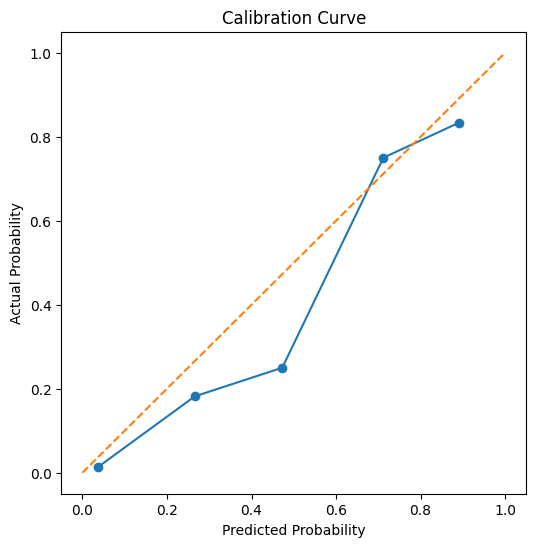

In [9]:
# Plot calibration curve

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")

plt.title("Calibration Curve")

plt.show()

In [10]:
# View feature importance weights

importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})

importance_df = importance_df.sort_values(by='importance',ascending=False)

print(importance_df)

             feature  importance
10  Total_Minutes_y1    0.100916
8             PTS_y1    0.098617
17           VORP_y1    0.088026
14             WS_y1    0.085386
0                Age    0.082698
2   Games_Started_y1    0.080532
1    Games_Played_y1    0.060477
11            PER_y1    0.054737
7             TOV_y1    0.048271
3             TRB_y1    0.038559
16            BPM_y1    0.035064
13           USG%_y1    0.028604
5             STL_y1    0.028508
20     PTS_per100_y1    0.025066
4             AST_y1    0.024180
18     TRB_per100_y1    0.022142
15          WS/48_y1    0.020828
12            TS%_y1    0.018814
19     AST_per100_y1    0.018212
6             BLK_y1    0.017039
9      Rookie_Season    0.016828
22       Position_PF    0.001766
25       Position_SG    0.001491
23       Position_PG    0.001409
24       Position_SF    0.001292
21        Position_C    0.000539


In [11]:
# Load in rookie dataset
rookie_pred_df = fs.load_rookie_prediction_features()

# Filter dataset for X and feed to model for predictions
X = rookie_pred_df.drop(columns=['Player', 'AS_After_Year_Two'])

probs = calibrated_model.predict_proba(X)

rookie_allstar_probs = probs[:, 1]

rookie_allstar_probs

array([0.23204607, 0.00841485, 0.00502502, 0.00275229, 0.00502502,
       0.00275229, 0.00275229, 0.00275229, 0.01962654, 0.0457288 ,
       0.04849524, 0.00614212, 0.00275229, 0.04309376, 0.06946909,
       0.45479116, 0.00275229, 0.00275229, 0.00275229, 0.02568714,
       0.43160679, 0.77179122, 0.00275229, 0.00275229, 0.00841485,
       0.11991373, 0.00502502, 0.6223382 , 0.05779995, 0.05503351,
       0.38327136, 0.23344156, 0.00275229, 0.05642561, 0.00275229,
       0.00502502, 0.00227273, 0.00275229, 0.00841485, 0.00502502,
       0.02568714, 0.05642561, 0.11214934, 0.00275229, 0.01238698,
       0.00502502, 0.01238698, 0.46858158, 0.00275229, 0.04215663,
       0.00275229, 0.01577681, 0.00275229, 0.09213554, 0.00841485,
       0.09059523, 0.03675514, 0.00275229, 0.8088644 , 0.00275229,
       0.02684482, 0.02832219, 0.00275229, 0.01577681, 0.00275229,
       0.00275229, 0.19505504, 0.00502502, 0.00275229, 0.00841485,
       0.05365917, 0.04309376, 0.02183742, 0.03675514, 0.04849

In [ ]:
# Load in rookie dataset and join predictions

current_rookie_df = pd.read_csv('/Users/natemekonen/Desktop/Data_Projects/nba_ml_career_projections/data/final/final_rookie_stats.csv', index_col=0)

current_rookie_df = current_rookie_df[['Player', 'Team_g_y1', 'Pos_g_y1', 'Age_g_y1', 'Images', 'logo']]

columns_to_rename = {
    'Team_g_y1' : 'Team',
    'Pos_g_y1' : 'Position',
    'Age_g_y1' : 'Age',
    'logo' : 'Team_Logo'
}

current_rookie_df = current_rookie_df.rename(columns=columns_to_rename)

current_rookie_df['Allstar_Prob'] = rookie_allstar_probs

current_rookie_df = current_rookie_df.sort_values(by='Allstar_Prob', ascending=False)

current_rookie_df.to_csv('/Users/natemekonen/Desktop/Data_Projects/nba_ml_career_projections/data/model_output/rookie_allstar_probs.csv')